## Python Replay Notebook

This notebook replays historical candles one bar at a time using the same VWAP probability band engine used by the live workflow.

It is not connected to TradingView. TradingView replay will require a separate Pine Script overlay later.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("✅ Project root added to Python path:")
print(PROJECT_ROOT)

✅ Project root added to Python path:
c:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine


In [2]:
from src.config import CONFIG
from src.loaders import load_tradingview_csv, assign_sessions
from src.engine import EngineState, update_engine_state
from src.replay import run_replay

### Load historical data

This loads the configured historical candle file and assigns session ids before replay.

In [3]:
USE_ONE_YEAR_DATA = True

if USE_ONE_YEAR_DATA:
    csv_path = PROJECT_ROOT / "data" / "historical" / "US100_cash_M1_NY_session_1y.csv"
else:
    csv_path = CONFIG["data_dir"] / CONFIG["csv_filename"]

    if not csv_path.is_absolute():
        csv_path = PROJECT_ROOT / csv_path

print("CSV path:", csv_path)
print("Exists:", csv_path.exists())

df = load_tradingview_csv(csv_path)
df = assign_sessions(df, CONFIG["sessions"])

print("Rows:", len(df))
display(df.head())
display(df.tail())

CSV path: c:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine\data\historical\US100_cash_M1_NY_session_1y.csv
Exists: True
✅ TradingView CSV loaded: 51,666 bars from c:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine\data\historical\US100_cash_M1_NY_session_1y.csv
Rows: 51666


,datetime,open,high,low,close,tick_volume,typical_price,session_date,session_id,session_name
0,2025-05-16 13:10:00+00:00,21352.65,21355.65,21352.65,21354.65,72,21354.316667,2025-05-16,2025-05-16_NewYork,NewYork
1,2025-05-16 13:11:00+00:00,21354.85,21358.65,21354.65,21356.75,72,21356.683333,2025-05-16,2025-05-16_NewYork,NewYork
2,2025-05-16 13:12:00+00:00,21356.65,21357.45,21355.65,21357.25,59,21356.783333,2025-05-16,2025-05-16_NewYork,NewYork
3,2025-05-16 13:13:00+00:00,21357.15,21357.45,21354.75,21354.95,50,21355.716667,2025-05-16,2025-05-16_NewYork,NewYork
4,2025-05-16 13:14:00+00:00,21354.95,21355.55,21354.15,21354.65,48,21354.783333,2025-05-16,2025-05-16_NewYork,NewYork


,datetime,open,high,low,close,tick_volume,typical_price,session_date,session_id,session_name
51661,2026-05-15 16:25:00+00:00,29113.95,29142.55,29113.95,29137.95,492,29131.483333,2026-05-15,2026-05-15_NewYork,NewYork
51662,2026-05-15 16:26:00+00:00,29138.25,29143.05,29130.75,29138.25,417,29137.350000,2026-05-15,2026-05-15_NewYork,NewYork
51663,2026-05-15 16:27:00+00:00,29138.05,29141.25,29121.05,29123.05,461,29128.450000,2026-05-15,2026-05-15_NewYork,NewYork
51664,2026-05-15 16:28:00+00:00,29123.25,29163.45,29123.25,29163.05,506,29149.916667,2026-05-15,2026-05-15_NewYork,NewYork
51665,2026-05-15 16:29:00+00:00,29163.45,29185.35,29162.35,29179.55,515,29175.750000,2026-05-15,2026-05-15_NewYork,NewYork


### Load probability tables

The replay engine needs a calibrated probability table. The marginal table is used as a fallback when exact trend/context bins are sparse.

In [4]:
tables_dir = PROJECT_ROOT / "artifacts" / "tables"

prob_table_path = tables_dir / "prob_table_trend.parquet"
marginal_table_path = tables_dir / "prob_table_marginal.parquet"

print("Trend table exists:", prob_table_path.exists(), prob_table_path)
print("Marginal table exists:", marginal_table_path.exists(), marginal_table_path)

prob_table = pd.read_parquet(prob_table_path)

if marginal_table_path.exists():
    marginal_table = pd.read_parquet(marginal_table_path)
else:
    marginal_table = prob_table

print("prob_table:", prob_table.shape)
print("marginal_table:", marginal_table.shape)

display(prob_table.head())

Trend table exists: True c:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine\artifacts\tables\prob_table_trend.parquet
Marginal table exists: True c:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine\artifacts\tables\prob_table_marginal.parquet
prob_table: (42, 9)
marginal_table: (21, 8)


,zone,trend_bin,outcome,count,total,prob,ci_lower,ci_upper,confidence
0,Z0,down,MR,0,64,0.0000,0.0000,0.0566,LOW
1,Z0,down,CONT,22,64,0.3438,0.2392,0.4660,LOW
2,Z0,down,NEU,42,64,0.6562,0.5340,0.7608,LOW
3,Z0,flat,MR,66,1256,0.0525,0.0415,0.0663,HIGH
4,Z0,flat,CONT,372,1256,0.2962,0.2716,0.3220,HIGH


### Run replay

This steps through the historical data one candle at a time and stores each `EngineState`.

In [5]:
def update_engine_state_with_marginal(state, bar, config, prob_table):
    return update_engine_state(
        state=state,
        bar=bar,
        config=config,
        prob_table=prob_table,
        marginal_table=marginal_table,
    )


states = []

for state in run_replay(
    df=df,
    config=CONFIG,
    prob_table=prob_table,
    EngineState=EngineState,
    update_engine_state=update_engine_state_with_marginal,
    speed=1e9,
):
    states.append(state)

print("Replay states:", len(states))

Replay states: 51666


### Convert replay states to a DataFrame

The resulting `replay_df` is the main output of this notebook.

In [6]:
rows = []

for s in states:
    bands = s.bands or {}
    context = s.context or {}
    probs = s.probabilities or {}

    rows.append({
        "datetime": s.datetime,
        "close": s.close,
        "reference": s.reference,
        "sigma": s.sigma,

        "band_1p": bands.get("1+"),
        "band_1n": bands.get("1-"),
        "band_2p": bands.get("2+"),
        "band_2n": bands.get("2-"),
        "band_3p": bands.get("3+"),
        "band_3n": bands.get("3-"),

        "z_score": s.z_score,
        "z_velocity": s.z_velocity,
        "zone": s.zone,

        "trend_bin": context.get("trend_bin"),
        "volume_bin": context.get("volume_bin"),
        "time_bin": context.get("time_bin"),
        "z_velocity_bin": context.get("z_velocity_bin"),

        "p_mr": probs.get("MR", {}).get("prob"),
        "p_cont": probs.get("CONT", {}).get("prob"),
        "p_neu": probs.get("NEU", {}).get("prob"),
        "edge_gap": probs.get("edge_gap"),
        "dominant": probs.get("dominant"),
        "actionable": probs.get("actionable"),
        "lookup_tier": probs.get("lookup_tier"),

        "bar_index": s.bar_index,
        "session_bar_count": s.session_bar_count,
    })

replay_df = pd.DataFrame(rows)

print(replay_df.shape)
display(replay_df.tail(20))

(51666, 26)


,datetime,close,reference,sigma,band_1p,band_1n,band_2p,band_2n,band_3p,band_3n,...,z_velocity_bin,p_mr,p_cont,p_neu,edge_gap,dominant,actionable,lookup_tier,bar_index,session_bar_count
51646,2026-05-15 16:10:00+00:00,29074.45,24798.913007,4284.334305,29083.247312,20514.578701,33367.581617,16230.244396,37651.915922,11945.910091,...,neutral,0.1660,0.4063,0.4277,0.0214,NEU,False,1,51647,51647
51647,2026-05-15 16:11:00+00:00,29070.35,24799.027845,4283.747549,29082.775394,20515.280296,33366.522944,16231.532746,37650.270493,11947.785197,...,neutral,0.1660,0.4063,0.4277,0.0214,NEU,False,1,51648,51648
51648,2026-05-15 16:12:00+00:00,29065.25,24799.162752,4282.951609,29082.114361,20516.211144,33365.065969,16233.259535,37648.017578,11950.307927,...,neutral,0.1660,0.4063,0.4277,0.0214,NEU,False,1,51649,51649
51649,2026-05-15 16:13:00+00:00,29062.75,24799.276152,4282.073934,29081.350087,20517.202218,33363.424021,16235.128284,37645.497955,11953.054350,...,neutral,0.1660,0.4063,0.4277,0.0214,NEU,False,1,51650,51650
51650,2026-05-15 16:14:00+00:00,29075.75,24799.388942,4281.816114,29081.205056,20517.572828,33363.021170,16235.756714,37644.837285,11953.940599,...,neutral,0.1660,0.4063,0.4277,0.0214,NEU,False,1,51651,51651
51651,2026-05-15 16:15:00+00:00,29068.75,24799.516044,4281.248721,29080.764766,20518.267323,33362.013487,16237.018602,37643.262208,11955.769880,...,neutral,0.1660,0.4063,0.4277,0.0214,NEU,False,1,51652,51652
51652,2026-05-15 16:16:00+00:00,29090.65,24799.663475,4281.688942,29081.352417,20517.974532,33363.041359,16236.285590,37644.730302,11954.596647,...,neutral,0.2223,0.1783,0.5994,0.3771,NEU,True,1,51653,51653
51653,2026-05-15 16:17:00+00:00,29099.05,24799.808876,4282.483122,29082.291997,20517.325754,33364.775119,16234.842632,37647.258241,11952.359510,...,neutral,0.2223,0.1783,0.5994,0.3771,NEU,True,1,51654,51654
51654,2026-05-15 16:18:00+00:00,29102.55,24799.959674,4283.393166,29083.352839,20516.566508,33366.746005,16233.173342,37650.139171,11949.780176,...,neutral,0.2223,0.1783,0.5994,0.3771,NEU,True,1,51655,51655
51655,2026-05-15 16:19:00+00:00,29098.95,24800.097237,4284.092499,29084.189736,20516.004738,33368.282235,16231.912238,37652.374735,11947.819739,...,neutral,0.2223,0.1783,0.5994,0.3771,NEU,True,1,51656,51656


### Replay checks

These checks show whether zones, trend bins, and probabilities are updating during replay.

In [7]:
print("Zones:")
display(replay_df["zone"].value_counts(dropna=False))

print("Trend bins:")
display(replay_df["trend_bin"].value_counts(dropna=False))

print("Dominant probabilities:")
display(replay_df["dominant"].value_counts(dropna=False))

print("Actionable:")
display(replay_df["actionable"].value_counts(dropna=False))

display(
    replay_df[
        [
            "datetime",
            "close",
            "reference",
            "sigma",
            "z_score",
            "zone",
            "trend_bin",
            "p_mr",
            "p_cont",
            "p_neu",
            "edge_gap",
            "dominant",
            "actionable",
            "lookup_tier",
        ]
    ].tail(30)
)

Zones:


zone
Z2+    24179
Z1+    22916
Z1-     1985
Z2-     1875
Z0       649
Z3+       48
Z3-       14
Name: count, dtype: int64

Trend bins:


trend_bin
flat    51666
Name: count, dtype: int64

Dominant probabilities:


dominant
NEU    51666
Name: count, dtype: int64

Actionable:


actionable
True     28750
False    22916
Name: count, dtype: int64

,datetime,close,reference,sigma,z_score,zone,trend_bin,p_mr,p_cont,p_neu,edge_gap,dominant,actionable,lookup_tier
51636,2026-05-15 16:00:00+00:00,29064.75,24797.539555,4291.869302,0.994255,Z1+,flat,0.1660,0.4063,0.4277,0.0214,NEU,False,1
51637,2026-05-15 16:01:00+00:00,29057.95,24797.691886,4290.446812,0.992964,Z1+,flat,0.1660,0.4063,0.4277,0.0214,NEU,False,1
51638,2026-05-15 16:02:00+00:00,29058.75,24797.839829,4289.117370,0.993424,Z1+,flat,0.1660,0.4063,0.4277,0.0214,NEU,False,1
51639,2026-05-15 16:03:00+00:00,29066.45,24797.973934,4288.187384,0.995403,Z1+,flat,0.1660,0.4063,0.4277,0.0214,NEU,False,1
51640,2026-05-15 16:04:00+00:00,29077.05,24798.104339,4287.770472,0.997942,Z1+,flat,0.1660,0.4063,0.4277,0.0214,NEU,False,1
51641,2026-05-15 16:05:00+00:00,29078.05,24798.242098,4287.411214,0.998227,Z1+,flat,0.1660,0.4063,0.4277,0.0214,NEU,False,1
51642,2026-05-15 16:06:00+00:00,29082.75,24798.384667,4287.273714,0.999322,Z1+,flat,0.1660,0.4063,0.4277,0.0214,NEU,False,1
51643,2026-05-15 16:07:00+00:00,29067.75,24798.531027,4286.460030,0.995978,Z1+,flat,0.1660,0.4063,0.4277,0.0214,NEU,False,1
51644,2026-05-15 16:08:00+00:00,29062.45,24798.672726,4285.438302,0.994945,Z1+,flat,0.1660,0.4063,0.4277,0.0214,NEU,False,1
51645,2026-05-15 16:09:00+00:00,29068.95,24798.781415,4284.749919,0.996597,Z1+,flat,0.1660,0.4063,0.4277,0.0214,NEU,False,1


### Quick replay plot

This plots the most recent bars from the replay output as a quick sanity check.

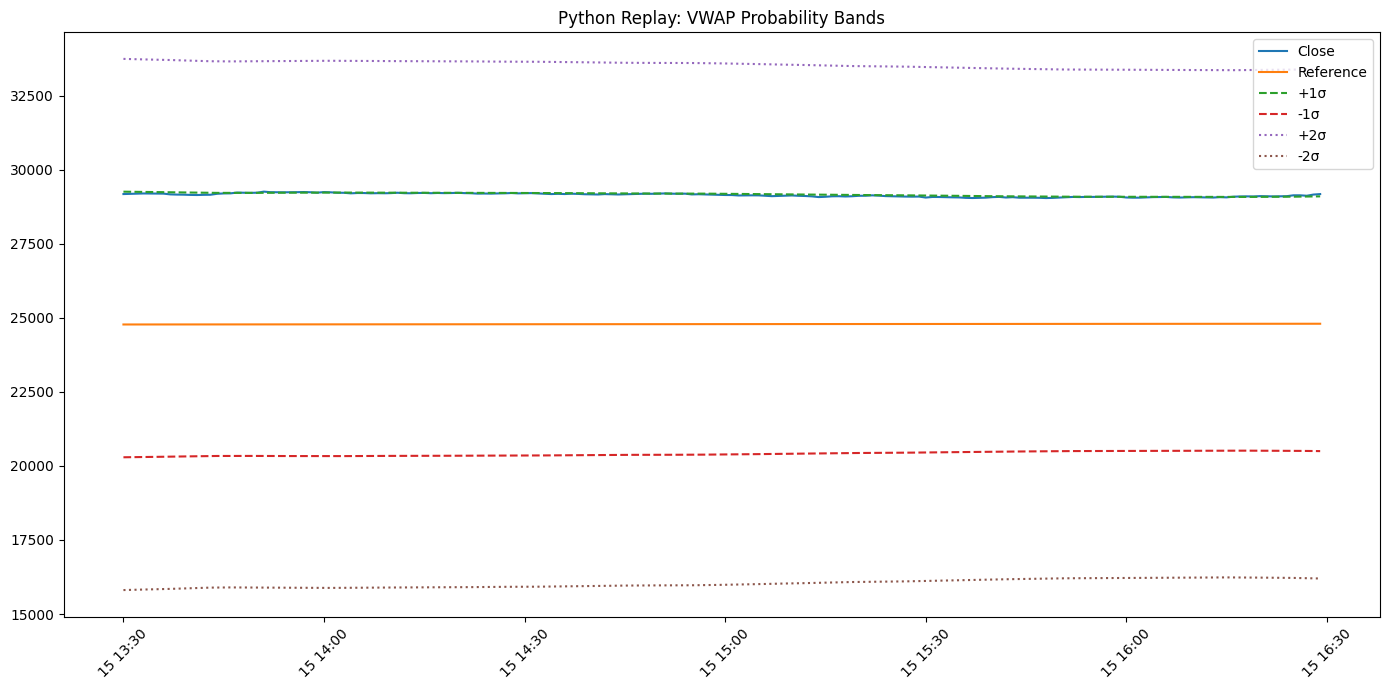

In [8]:
plot_df = replay_df.tail(CONFIG.get("plot_last_n_bars", 180)).copy()

plt.figure(figsize=(14, 7))

plt.plot(plot_df["datetime"], plot_df["close"], label="Close")
plt.plot(plot_df["datetime"], plot_df["reference"], label="Reference")

plt.plot(plot_df["datetime"], plot_df["band_1p"], linestyle="--", label="+1σ")
plt.plot(plot_df["datetime"], plot_df["band_1n"], linestyle="--", label="-1σ")

plt.plot(plot_df["datetime"], plot_df["band_2p"], linestyle=":", label="+2σ")
plt.plot(plot_df["datetime"], plot_df["band_2n"], linestyle=":", label="-2σ")

plt.title("Python Replay: VWAP Probability Bands")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Save replay output

The replay output is saved locally for inspection. It should usually not be committed to Git.

In [9]:
output_path = tables_dir / "replay_output.parquet"
replay_df.to_parquet(output_path, index=False)

print("Saved:", output_path)

Saved: c:\Users\k2587979\Documents\GitHub Projects\VWAP-probability-band-engine\VWAP-probability-band-engine\artifacts\tables\replay_output.parquet
